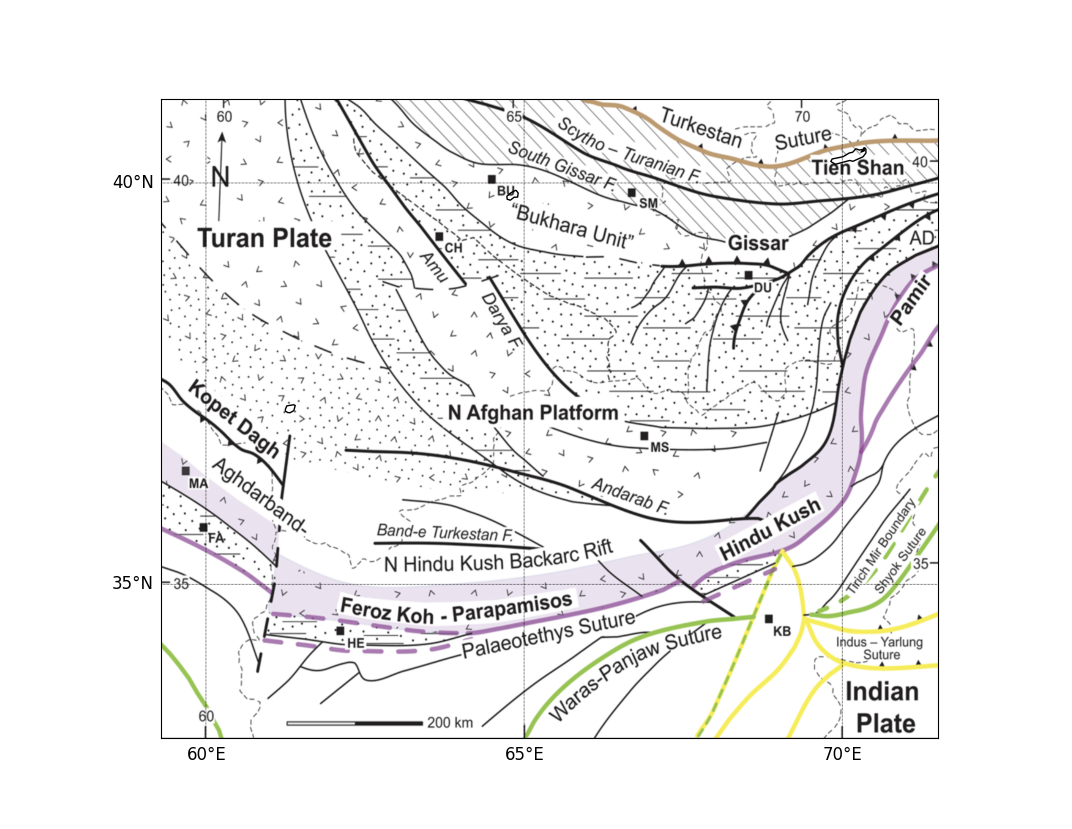

TypeError: input must be a scalar

In [1]:
### imports ###
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import matplotlib.image as mpimg 
from mpl_toolkits.basemap import Basemap


### interactive pygmt the function ##
%matplotlib widget

png_path = "figures/Siehl, A., 2017. Figure 3.png"
llcrnrlat = 33
urcrnrlat = 41 
llcrnrlon = 59.3
urcrnrlon = 71.5 
grid_freq = 5


# determine image dimension
img = Image.open(png_path)
width, height = img.size # (width,height) tuple in pixels
DPI_horz, DPI_vert = img.info.get('dpi')

assert DPI_horz == DPI_vert

fig = plt.figure(figsize=(width/DPI_horz, height/DPI_horz))
ax1 = plt.subplot(111)

# creating matplotlib basemap for overlay
m = Basemap(projection='merc', resolution='i',\
                        llcrnrlat=llcrnrlat, urcrnrlat=urcrnrlat,\
                        llcrnrlon=llcrnrlon, urcrnrlon=urcrnrlon)

m.drawcoastlines() # draws coastlines on matplotlib. this makes sure that everything is aligned

# plotting parallels and meridians, annotating axis
parallels = np.arange(-90, 90, grid_freq)
meridians = np.arange(-180, 180, grid_freq)
m.drawparallels(parallels, labels=[1,0,0,0], fontsize=12, linewidth=0.5) # label parallels on right and top
m.drawmeridians(meridians, labels=[0,0,0,1], fontsize=12, linewidth=0.5) # meridians on bottom and left

# plotting pygmt png image in bottom layer
img = mpimg.imread(png_path)
m.imshow(img, origin='upper')


def pos_to_lonlat(x, y):
  lon, lat = m(x, y, inverse=True)
  return lon, lat

pos_fault = [] # in format [[None, None], [x, y], [x, y], ...]
lonlat_fault = []

def onclick(event):
  pos_fault.append([event.xdata, event.ydata])

  lon, lat = pos_to_lonlat(pos_fault[-1][0], pos_fault[-1][1]) # pos[-1] represents last click (list with x, y)
  lonlat_fault.append([lon, lat]) # converts x y to lon lat and appends

  ax1.set_title(f'Click {len(pos_fault)}: {lon}, {lat}') 

cid=fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()


In [2]:
import pandas as pd
## fault saving and printing
fault_pts = np.array(pos_fault[:])

ax1.plot(fault_pts[:,0],fault_pts[:,1], 'r-') # print fault

fault_df = pd.DataFrame(lonlat_fault)
print(fault_df)

# saved as Herat_trace.xy
# based on Siehl, A., 2017. Structural setting and evolution of the Afghan orogenic segment–a review. Geological Society, London, Special Publications, 427(1), pp.57-88.


            0          1
0   59.356540  36.308605
1   60.126623  35.889556
2   60.723831  35.493873
3   61.132447  35.211877
4   61.006719  34.606142
5   61.729654  34.554384
6   63.395549  34.372978
7   63.662721  34.372978
8   64.197065  34.347031
9   65.517208  34.580267
10  66.743055  34.774133
11  66.947363  34.838653
12  67.167387  34.903124
13  67.434559  35.044780
14  67.638866  34.928898
15  67.937470  35.134798
16  68.440382  35.314534
17  68.990442  35.404253
18  69.257613  35.481076
19  69.509069  35.672811
20  70.074845  36.169170
21  70.310585  36.775783
22  70.294869  37.052224
23  70.326301  37.689201
24  70.750632  38.370057
25  71.112100  38.800028
26  71.473568  38.983512
